# Stage 7 — Fusion (Transformer + Acoustic Features)

This notebook analyzes **end-to-end fusion models** where we jointly train:

- a transformer encoder (HuBERT, WavLM), and  
- an MLP head that takes the **concatenation** of the mean-pooled encoder embedding and standardized acoustic features.

We compare **only the 2 fusion-trained models**: `hubert_base_ls960` and `wavlm` — their transformer-only (base) vs fusion performance.

All use the shared **speaker-disjoint** split from `results/split.json`, and thresholds are tuned on validation F1.

In [23]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Results dir: project_root/results (works from notebooks/ or project root)
root = Path.cwd()
if root.name == "notebooks":
    root = root.parent
OUTPUTS_DIR = root / "results"

base_path = OUTPUTS_DIR / "transformer_results.json"
fusion_path = OUTPUTS_DIR / "fusion_models_results.json"

with open(base_path) as f:
    base_results = json.load(f)

with open(fusion_path) as f:
    fusion_results = json.load(f)

# Focus on the 2 models we ran fusion on (train_fusions_models.py)
FUSION_MODELS = ["wavlm", "hubert_base_ls960"]
base_results = {k: base_results[k] for k in FUSION_MODELS}
fusion_results = {k: fusion_results[k] for k in FUSION_MODELS}
base_results.keys(), fusion_results.keys()

(dict_keys(['wavlm', 'hubert_base_ls960']),
 dict_keys(['wavlm', 'hubert_base_ls960']))

In [24]:
rows = []
for short, b in base_results.items():
    f = fusion_results[short]
    rows.append({
        "Model": short,
        "Base Test AUC": b["auc_roc"],
        "Base Test F1": b["f1"],
        "Fusion Test AUC": f["auc_roc"],
        "Fusion Test F1": f["f1"],
    })

df_compare = pd.DataFrame(rows)
df_compare.sort_values("Base Test AUC", ascending=False)

,Model,Base Test AUC,Base Test F1,Fusion Test AUC,Fusion Test F1
1,hubert_base_ls960,0.958183,0.659593,0.912847,0.718598
0,wavlm,0.884322,0.711340,0.964874,0.846890


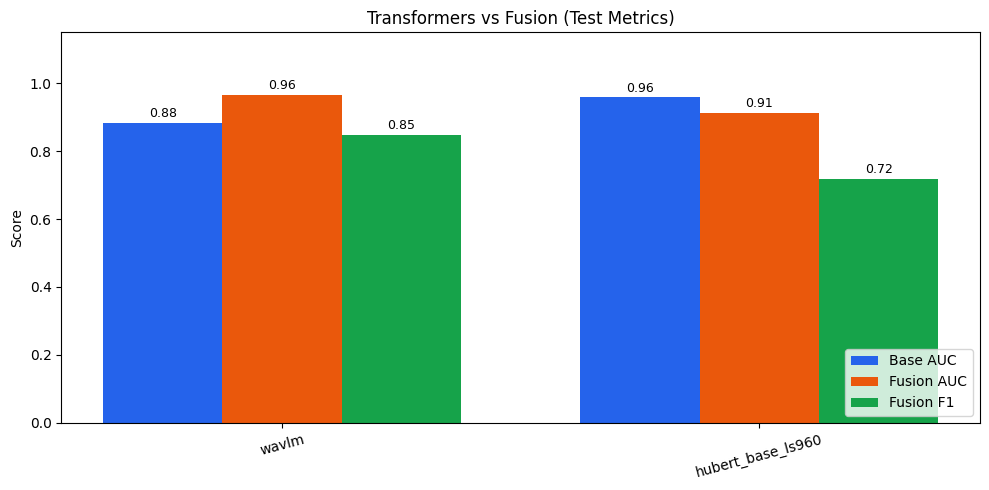

In [25]:
models = df_compare["Model"].tolist()
x = np.arange(len(models))
width = 0.25

# Distinct colors for clarity
colors = {"Base AUC": "#2563eb", "Fusion AUC": "#ea580c", "Fusion F1": "#16a34a"}

fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - width, df_compare["Base Test AUC"], width, label="Base AUC", color=colors["Base AUC"])
b2 = ax.bar(x, df_compare["Fusion Test AUC"], width, label="Fusion AUC", color=colors["Fusion AUC"])
b3 = ax.bar(x + width, df_compare["Fusion Test F1"], width, label="Fusion F1", color=colors["Fusion F1"])

ax.bar_label(b1, labels=[f"{v:.2f}" for v in df_compare["Base Test AUC"]], padding=2, fontsize=9)
ax.bar_label(b2, labels=[f"{v:.2f}" for v in df_compare["Fusion Test AUC"]], padding=2, fontsize=9)
ax.bar_label(b3, labels=[f"{v:.2f}" for v in df_compare["Fusion Test F1"]], padding=2, fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15)
ax.set_ylabel("Score")
ax.set_ylim(0, 1.15)
ax.set_title("Transformers vs Fusion (Test Metrics)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [26]:
def plot_confusions(short):
    b = base_results[short]
    f = fusion_results[short]

    cm_base = np.array(b["confusion_matrix"])
    cm_fus  = np.array(f["confusion_matrix"])

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    for ax, cm, title in zip(
        axes,
        [cm_base, cm_fus],
        [f"{short} (base)", f"{short} (fusion)"],
    ):
        im = ax.imshow(cm, cmap="Blues")
        ax.set_title(title)
        ax.set_xticks([0, 1])
        ax.set_xticklabels(["Real", "Fake"])
        ax.set_yticks([0, 1])
        ax.set_yticklabels(["Real", "Fake"])
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")
        for i in range(2):
            for j in range(2):
                ax.text(j, i, int(cm[i, j]), ha="center", va="center", color="black")
    plt.tight_layout()
    plt.show()

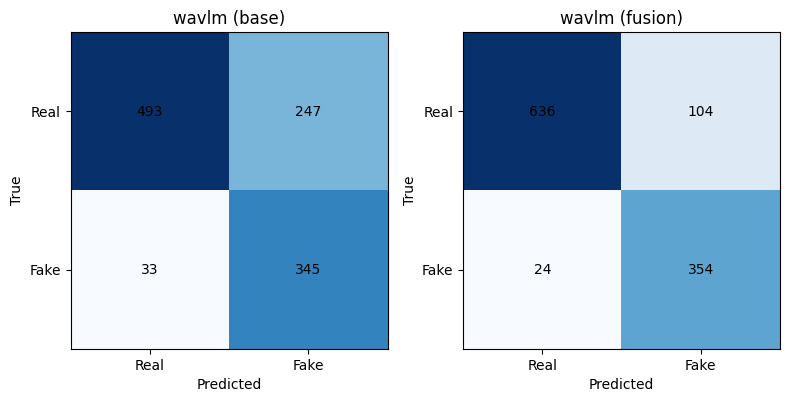

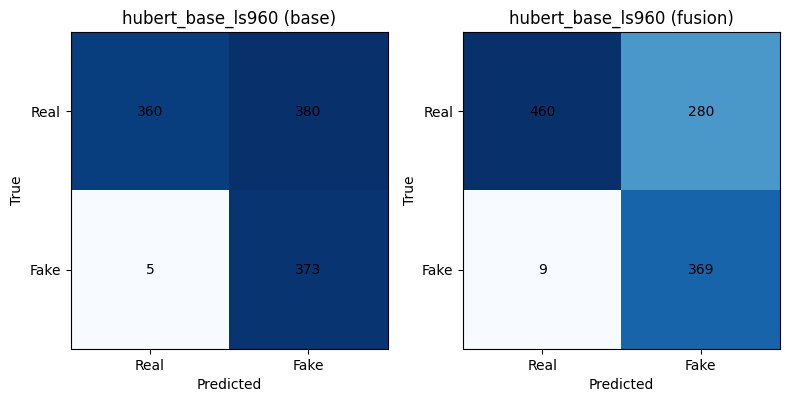

In [27]:
# Confusion matrices for the 2 fusion models
for short in FUSION_MODELS:
    plot_confusions(short)

## Summary

- **Base transformers** are the fine-tuned models from Stage 6 (encoder + classification head).
- **Fusion models** reuse the same encoders but add a jointly trained MLP that combines:
  - the mean-pooled encoder embedding, and
  - standardized acoustic features from `acoustic_features.csv`.

All experiments:

- use the same speaker-disjoint train/validation/test split (`results/split.json`),
- tune probability thresholds on validation F1,
- report test metrics using the chosen threshold.

The table and bar chart above show whether end-to-end fusion improves AUC/F1 compared to transformer-only baselines for each architecture.